# Mean Reversion Strategy Bitcoin - Strategy

1. [Download Data](#download-data)
2. [Test Stationarity](#test-stationarity)
3. [Cointegration Test](#cointegration-test)
4. [Modeling the Strategy](#modeling-the-strategy)


# Download Data

Data can be downloaded from sources such as Yahoo Finance, Polygon, Metatrader...

---

C:\Users\jango\AppData\Local\Temp\ipykernel_33772\192592863.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bitcoin = yf.download(
[*********************100%***********************]  1 of 1 completed
C:\Users\jango\AppData\Local\Temp\ipykernel_33772\192592863.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  strategy = yf.download(
[*********************100%***********************]  1 of 1 completed


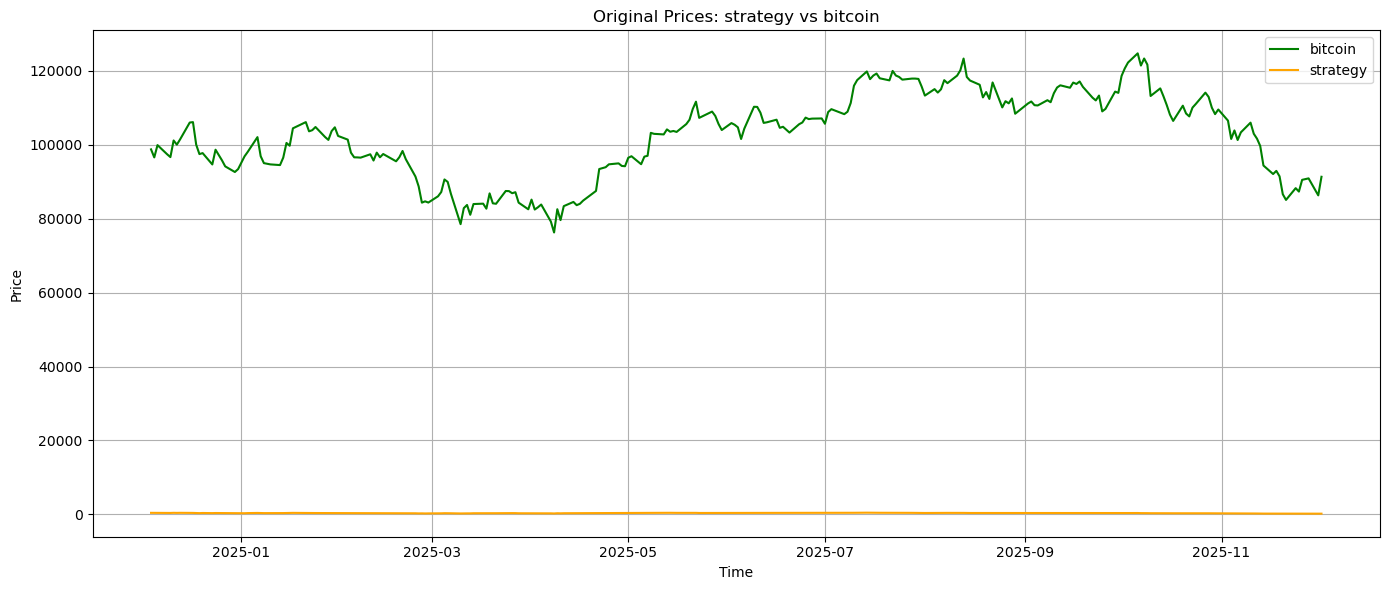

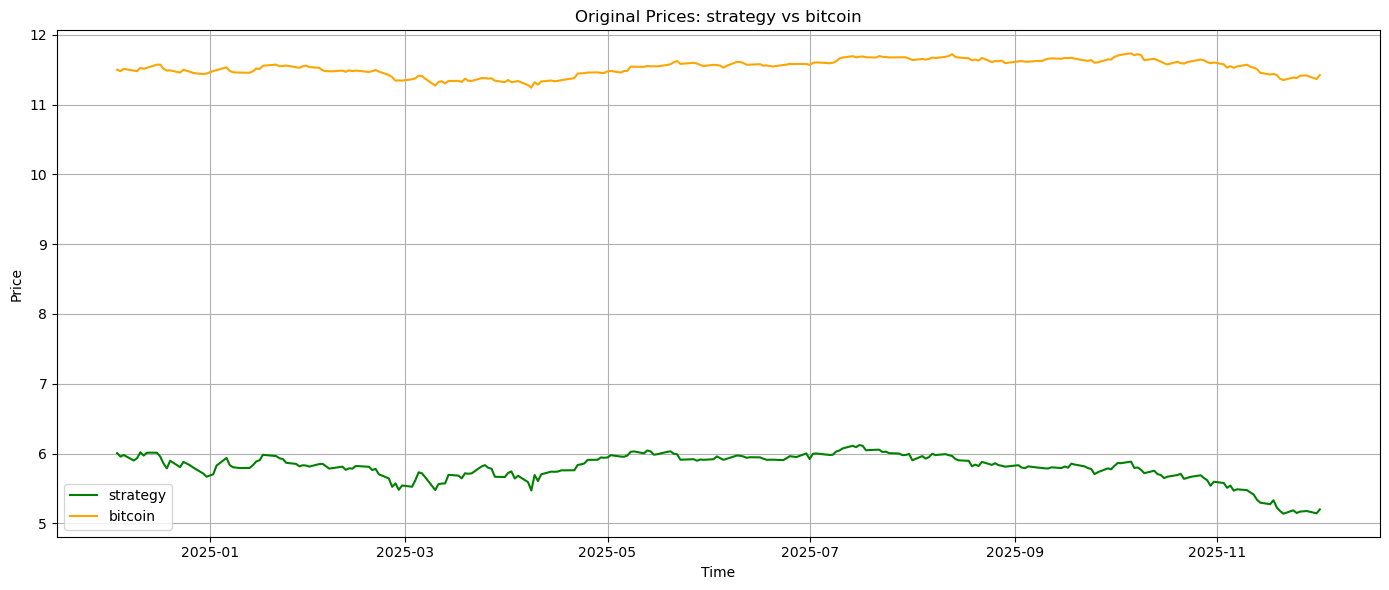

Bitcoin Buy-and-Hold Return (last 365 days): -7.51%
Strategy Buy-and-Hold Return (last 365 days): -55.34%
BTC Sharpe ratio diario: 0.00
Strategy Sharpe ratio diario: -0.04


In [12]:
# ===========================================
# Import required libraries
# ===========================================
import pandas as pd  # For data manipulation (install: pip install pandas)
import yfinance as yf  # Yahoo Finance API wrapper (install: pip install yfinance)
from datetime import datetime, timedelta  # To work with time ranges
from yahooquery import search  # For searching assets (install: pip install yahooquery)
import os  # To interact with the file system
import matplotlib.pyplot as plt  # For visualization (install: pip install matplotlib)
import json #For data manipulation
import numpy as np

# ===========================================
# Load environment variables
# ===========================================


bitcoin = yf.download(
    tickers= "BTC-USD",
    interval='1d',
    period='365d',
    progress=True,
    threads=True  # Enable multi-threading for faster downloading
)

strategy = yf.download(
    tickers= "MSTR",
    interval='1d',
    period='365d',
    progress=True,
    threads=True  # Enable multi-threading for faster downloading
)

btc_close = bitcoin['Close']
strategy_close = strategy['Close'] 

btc_close = btc_close['BTC-USD']  #  Series
strategy_close = strategy_close['MSTR']  #  Series

bitcoin = np.log(bitcoin)
strategy = np.log(strategy)

common_dates = bitcoin.index.intersection(strategy.index)
bitcoin = bitcoin.loc[common_dates]
strategy = strategy.loc[common_dates]

btc_close = btc_close.loc[common_dates]
strategy_close = strategy_close.loc[common_dates]


# ======== Plot original prices: bitcoin vs strategy ===========
plt.figure(figsize=(14, 6))
plt.plot(btc_close, label='bitcoin', color='green')
plt.plot(strategy_close, label='strategy', color='orange')
plt.title('Original Prices: strategy vs bitcoin')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ======== Plot original prices: bitcoin vs strategy ===========
plt.figure(figsize=(14, 6))
plt.plot(strategy[('Close','MSTR')], label='strategy', color='green')
plt.plot(bitcoin[( 'Close','BTC-USD')], label='bitcoin', color='orange')
plt.title('Original Prices: strategy vs bitcoin')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Buy-and-hold return in percentage
btc_return = (btc_close.iloc[-1] - btc_close.iloc[0]) / btc_close.iloc[0] * 100
strategy_return = (strategy_close.iloc[-1] - strategy_close.iloc[0]) / strategy_close.iloc[0] * 100

print(f"Bitcoin Buy-and-Hold Return (last 365 days): {btc_return:.2f}%")
print(f"Strategy Buy-and-Hold Return (last 365 days): {strategy_return:.2f}%")

# Retornos diarios
btc_daily_ret = btc_close.pct_change().dropna()
strategy_daily_ret = strategy_close.pct_change().dropna()

# Sharpe ratio anualizado (suponiendo 252 días de trading)
btc_sharpe = (btc_daily_ret.mean() / btc_daily_ret.std()) 
strategy_sharpe = (strategy_daily_ret.mean() / strategy_daily_ret.std()) 
print(f"BTC Sharpe ratio diario: {btc_sharpe:.2f}")
print(f"Strategy Sharpe ratio diario: {strategy_sharpe:.2f}")



### Create Stationary Series Using OLS

The stationary series is calculated by subtracting the trend fitted by an Ordinary Least Squares (OLS) model, returning the residuals as the stationary series.

---

**Alpha**: The intercept term in the OLS regression, representing the constant part of the relationship between the two series.

**Beta**: The slope term in the OLS regression, representing the sensitivity of the dependent variable (the first asset) to the independent variable (the second asset). It indicates the strength and direction of the relationship between the two series.


C:\Users\jango\AppData\Local\Temp\ipykernel_33772\2980190915.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hedge_ratio = model.params[1]  # The coefficient of the second asset (EWA)


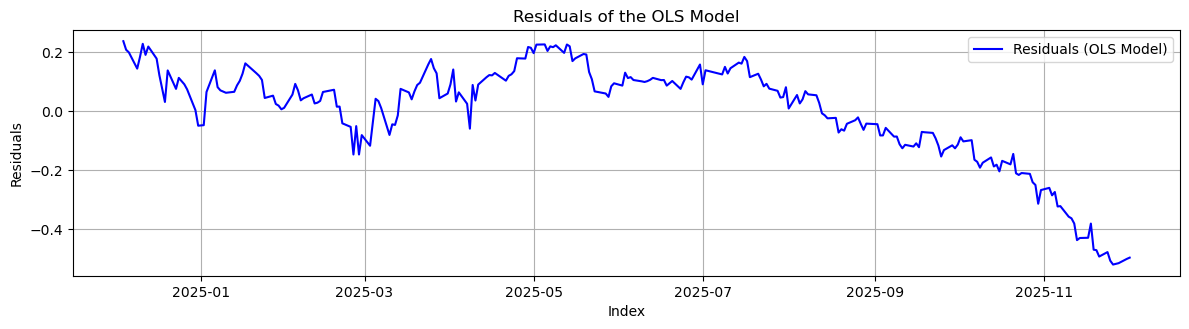

In [13]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from arch.__future__ import reindexing
from arch import unitroot

# Step 1: Define the dependent and independent variables
Y = strategy[('Close','MSTR')]
X = bitcoin[( 'Close','BTC-USD')]
X = sm.add_constant(X)  # Add an intercept (constant) to the model

# Step 2: Fit the OLS model
model = sm.OLS(Y, X).fit()
hedge_ratio = model.params[1]  # The coefficient of the second asset 

# residuals are the difference between the observed and predicted values from the model
residuals = model.resid  # Residuals from the OLS model

# Plot both the residuals from the OLS model and the manually calculated residuo
plt.figure(figsize=(12, 6))

# Plot residuals from the OLS model
plt.subplot(2, 1, 1)  # First plot
plt.plot(residuals, label='Residuals (OLS Model)', color='blue')
plt.title('Residuals of the OLS Model')
plt.xlabel('Index')
plt.ylabel('Residuals')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# Test Stationarity

To test for stationarity, you can use the **Augmented Dickey-Fuller (ADF)** test (differents results depending on which is the independent variable).

---

In [14]:
from statsmodels.tsa.stattools import adfuller
from hurst import compute_Hc
from arch.unitroot import VarianceRatio

# Assume 'residuals' is already a list or 1D array-like series of residuals
# Example: residuals = [values from your cointegration model]

# --- ADF Test ---
adf_result = adfuller(residuals)
adf_statistic = adf_result[0]
adf_p_value = adf_result[1]

print("ADF Test:")
print(f"Statistic: {adf_statistic}")
print(f"P-value: {adf_p_value}")
if adf_p_value < 0.05:
    print("Residuals are stationary (reject null hypothesis of unit root).")
else:
    print("Residuals are not stationary (fail to reject null hypothesis).")

# Ensure residuals are strictly positive
residuals1 = [r - min(residuals) + 1 for r in residuals]


# --- Hurst Exponent --- Not recomended for 
H, c, _ = compute_Hc(residuals1, kind='price')
print("\nHurst Exponent:")
print(f"H: {H}")
if H < 0.5:
    print("Series shows mean-reverting behavior.")
elif H > 0.5:
    print("Series shows trending behavior.")
else:
    print("Series behaves like a random walk.")

# --- Variance Ratio Test ---
vr_test = VarianceRatio(residuals1, lags=2)
print("\nVariance Ratio Test:")
print(f"Variance Ratio: {vr_test.vr}")
print(f"P-value: {vr_test.pvalue}")
if vr_test.vr < 1:
    print("Variance ratio suggests mean reversion.")
elif vr_test.vr > 1:
    print("Variance ratio suggests momentum.")
else:
    print("Variance ratio suggests random walk.")




ADF Test:
Statistic: 0.747445551591886
P-value: 0.9907386878666747
Residuals are not stationary (fail to reject null hypothesis).

Hurst Exponent:
H: 0.5593999142912018
Series shows trending behavior.

Variance Ratio Test:
Variance Ratio: 0.7791604530846407
P-value: 0.014860480139345489
Variance ratio suggests mean reversion.


## Half-Life for Mean Reverting Process

This section estimates the half-life of mean reversion for a stationary portfolio 
derived from cointegrated assets using the first eigenvector from the Johansen test.



In [15]:


# Construyes Y como matriz con columnas para cada activo
Y = pd.DataFrame({
    'strategy': strategy[('Close', 'MSTR')],
    'bitcoin': bitcoin[('Close', 'BTC-USD')]
})

# Multiply the eigenvector with the time series 'y3', repeat the eigenvector to match the shape of y3
# and sum the result across the specified axis (axis=1) to get 'yport'
yport = np.sum(np.tile(hedge_ratio, (Y.shape[0], 1)) * Y, axis=1)

# Create the lagged version of 'yport' (equivalent to lag(yport, 1) in MATLAB)
ylag = pd.Series(yport).shift(1)

# Calculate deltaY (the difference between 'yport' and its lagged version)
deltaY = yport - ylag

# Remove the first value, which is NaN due to the lag
deltaY = deltaY[1:]
ylag = ylag.dropna()  # Drop the NaN value from the lagged series

# Fit an OLS (Ordinary Least Squares) regression model
X = sm.add_constant(ylag)  # Add the constant term (intercept) to the independent variable
model = sm.OLS(deltaY, X)  # Create the OLS model with deltaY as the dependent variable and ylag as the independent variable
results_ols = model.fit()  # Fit the model

# Get the hedge ratio (beta[1]), which represents the coefficient for the lagged series
print(results_ols.params)

hedge_ratio = results_ols.params[0]

print(hedge_ratio)
# Calculate the half-life, which is the time it takes for the hedge ratio to halve
half_life = -np.log(2) / hedge_ratio

# Print the hedge ratio and the half-life in days
print(f'Hedge Ratio: {hedge_ratio}')
print(f'Half-Life: {half_life} days')



const    0.320172
0       -0.020301
dtype: float64
-0.020301473941381633
Hedge Ratio: -0.020301473941381633
Half-Life: 34.142702276757575 days


# Modeling the Strategy

You will use techniques such as z-scores, Bollinger Bands, and linear regression to model your strategy.

---

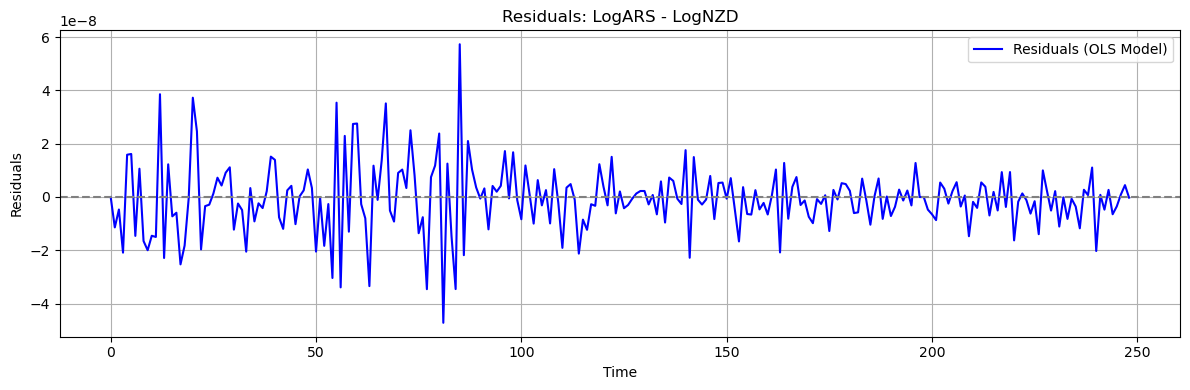

yport head:
 0   -2.687738e-14
1   -1.142291e-08
2   -4.706784e-09
3   -2.088970e-08
4    1.585516e-08
dtype: float64
yport index:
 RangeIndex(start=0, stop=249, step=1)
zScore head:
 0         NaN
1   -0.707107
2    0.116671
3   -1.283792
4    1.466222
dtype: float64
zScore index:
 RangeIndex(start=0, stop=249, step=1)
Positions head:
    bitcoin  strategy
0      0.0 -0.000000
1      0.0 -0.000000
2      0.0 -0.000000
3      1.0 -0.003750
4     -1.0  0.003903
Positions index:
 RangeIndex(start=0, stop=249, step=1)
log_bitcoin head:
 0    11.500534
1    11.478267
2    11.512132
3    11.486917
4    11.479115
dtype: float64
log_strategy head:
 0    6.006353
1    5.956873
2    5.978911
3    5.900828
4    5.933094
dtype: float64
real_prices head:
         bitcoin    strategy
0  98768.531250  406.000000
1  96593.570312  386.399994
2  99920.710937  395.010010
3  97432.718750  365.339996
4  96675.429687  377.320007
real_prices index:
 RangeIndex(start=0, stop=249, step=1)
positions_lagged hea

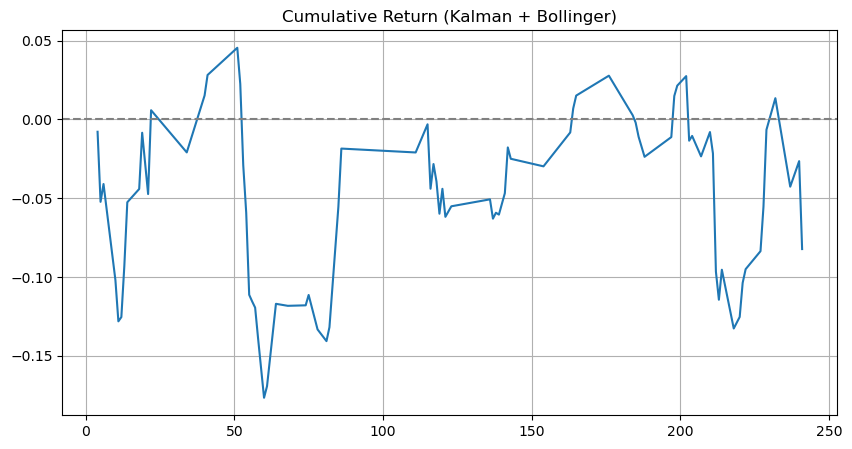

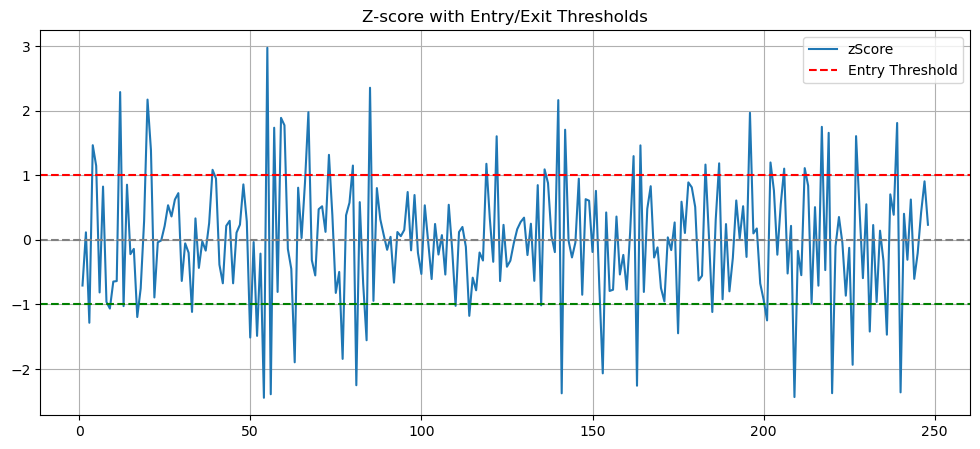

In [34]:
import numpy as np
import pandas as pd

# --- Kalman Filter Regression for Dynamic Hedge Ratio ---
def ensure_series(x, index):
    if isinstance(x, pd.Series):
        return x
    if isinstance(x, pd.DataFrame):
        x = x.iloc[:, 0]
    return pd.Series(x.values.flatten(), index=index)


def kalman_regression(x, y, delta=0.0001, Ve=0.001):
    x = np.hstack([x, np.ones((x.shape[0], 1))])  # Add intercept term
    yhat = np.full(y.shape, np.nan)
    e = np.full(y.shape, np.nan)
    Q = np.full(y.shape, np.nan)
    
    P = 1e5 * np.eye(2)
    beta = np.full((2, x.shape[0]), np.nan)
    Vw = (delta / (1 - delta)) * np.eye(2)
    beta[:, 0] = 0
    
    for t in range(len(y)):
        if t > 0:
            beta[:, t] = beta[:, t - 1]
            R = P + Vw
        else:
            R = P
        

        yhat[t] = x[t, :] @ beta[:, t]
        Q[t] = x[t, :] @ R @ x[t, :].T + Ve
        e[t] = y[t] - yhat[t]
        
        K = R @ x[t, :].T / Q[t]
        beta[:, t] = beta[:, t] + K * e[t]
        P = R - np.outer(K, x[t, :]) @ R

    return beta, yhat, e, Q


x = btc_close.values.flatten()
y = strategy_close.values.flatten()
# Extract only price data, dates are not necessary here

# Step 0: Run Kalman filter regression
beta, yhat, e, Q = kalman_regression(x.reshape(-1, 1), y)

hedge_ratio = beta[0, :]   # dynamic hedge ratio
intercept = beta[1, :]     # dynamic intercept
yport = y - hedge_ratio * x - intercept  # Spread itself as portfolio
yport = pd.Series(yport)



plt.figure(figsize=(12, 4))
plt.plot(yport, label='Residuals (OLS Model)', color='blue')
plt.axhline(y=0, linestyle='--', color='gray')
plt.title(f'Residuals: LogARS - LogNZD')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Moving average and standard deviation functions
def moving_avg(x, window):
    return x.rolling(window=window, min_periods=1).mean()

def moving_std(x, window):
    return x.rolling(window=window, min_periods=1).std()


lookback = round(half_life)

# Z-score signal
zScore = (yport - moving_avg(yport, lookback)) / moving_std(yport, lookback)
entry_threshold = 1
entryZscore = 1
exitZscore = 0
longsEntry = zScore < -entryZscore
longsExit = zScore >= -exitZscore
shortsEntry = zScore > entryZscore
shortsExit = zScore <= exitZscore

# --- Inspect yport y zScore ---
print("yport head:\n", yport.head())
print("yport index:\n", yport.index)
print("zScore head:\n", zScore.head())
print("zScore index:\n", zScore.index)

# --- Positions ---
numUnitsLong = pd.Series(np.nan, index=yport.index)
numUnitsShort = pd.Series(np.nan, index=yport.index)

numUnitsLong.iloc[0] = 0
numUnitsLong[longsEntry] = 1
numUnitsLong[longsExit] = 0
numUnitsLong = numUnitsLong.ffill()

numUnitsShort.iloc[0] = 0
numUnitsShort[shortsEntry] = -1
numUnitsShort[shortsExit] = 0
numUnitsShort = numUnitsShort.ffill()

numUnits = numUnitsLong + numUnitsShort
positions = pd.DataFrame(index=yport.index)
positions['bitcoin'] = numUnits
positions['strategy'] = -numUnits * hedge_ratio

# --- Logs para positions ---
print("Positions head:\n", positions.head())
print("Positions index:\n", positions.index)

# --- Log prices ---
log_bitcoin = ensure_series(bitcoin, yport.index)
log_strategy = ensure_series(strategy, yport.index)

print("log_bitcoin head:\n", log_bitcoin.head())
print("log_strategy head:\n", log_strategy.head())

# Convert log-prices back to real prices
real_prices = np.exp(pd.DataFrame({
    'bitcoin': log_bitcoin,
    'strategy': log_strategy
}))
print("real_prices head:\n", real_prices.head())
print("real_prices index:\n", real_prices.index)

# Align indices and shift positions by one day
positions_lagged = positions.shift(1).reindex(real_prices.index).fillna(0)
print("positions_lagged head:\n", positions_lagged.head())

# Calculate position values and PnL
position_value = positions_lagged * real_prices
real_prices_diff = real_prices.diff().fillna(0)
pnl = (positions_lagged * real_prices_diff).sum(axis=1)
capital = position_value.abs().sum(axis=1)
ret = pnl / capital.replace(0, np.nan)

results = pd.DataFrame({
    'pnl': pnl,
    'ret': ret,
    'zScore': zScore,
    'spread': yport
}).dropna(subset=['ret'])
results['cum_ret'] = results['ret'].cumsum()

# --- Strategy performance logs ---
print("Results head:\n", results.head())
print("Results index:\n", results.index)
print("Cumulative return last value:", results['cum_ret'].iloc[-1])

# --- Metrics ---
avg_daily_return = results['ret'].mean()
std_daily_return = results['ret'].std()
sharpe_ratio = avg_daily_return / std_daily_return * np.sqrt(252)  # anualizado
cum_max = results['cum_ret'].cummax()
drawdown = results['cum_ret'] - cum_max
max_drawdown = drawdown.min()

print(f"Average daily return: {avg_daily_return:.5f}")
print(f"Daily volatility: {std_daily_return:.5f}")
print(f"Sharpe ratio (annualized): {sharpe_ratio:.2f}")
print(f"Max drawdown: {max_drawdown:.5f}")

# --- Plots ---
plt.figure(figsize=(10,5))
results['cum_ret'].plot(title='Cumulative Return (Kalman + Bollinger)')
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(zScore, label='zScore')
plt.axhline(entryZscore, color='red', linestyle='--', label='Entry Threshold')
plt.axhline(-entryZscore, color='green', linestyle='--')
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.title('Z-score with Entry/Exit Thresholds')
plt.grid(True)
plt.show()

## Strategy Evaluation

### Absolute vs Risk-Adjusted Return

The strategy clearly shows a negative performance, which validates the initial statistical analysis that indicated a low probability of stationarity.


